<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/54_MetaLearner_AI_shock_panel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. Meta-Learner 실습: ChatGPT 출시 이후 AI 종목의 이질적 반응
## Causal ML Meta-Learners — Bilingual Inference Version

### 학습 목표
1. ATE와 CATE의 차이를 이해한다.
2. S-Learner, T-Learner, X-Learner를 구현한다.
3. 이질적 처치효과(CATE)의 분포를 확인한다.
4. learner별 결과를 비교한다.
5. 결과를 영어와 한글로 자동 해석한다.

### 교육용 연구 질문
**ChatGPT 출시 이후 AI 관련 종목은 어떤 특성 구간에서 상대적으로 더 큰 반응을 보였는가?**

> 이 실습은 Causal ML 구조 학습용입니다. 종목의 산업군 자체를 treatment로 사용하는 것은 강한 외생적 처치가 아니므로, 논문 수준의 인과식별과는 구분해야 합니다.

## 1. 조건부 평균 처치효과(CATE)

\[
\tau(x)
=
E[Y(1)-Y(0)\mid X=x]
\]

- \(Y\): 향후 5거래일 수익률
- \(T\): AI 관련 종목 여부
- \(X\): 모멘텀, 변동성, 거래량 등

## 2. 라이브러리 준비

In [2]:
# ============================================================
# STEP 1. Import libraries
# ============================================================

!pip install -q yfinance pandas numpy matplotlib scikit-learn econml

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from econml.metalearners import (
    TLearner,
    SLearner,
    XLearner
)

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

print("Libraries loaded successfully.")
print("라이브러리를 정상적으로 불러왔습니다.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 679.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 13.1 MB/s eta 0:00:00
Libraries loaded successfully.
라이브러리를 정상적으로 불러왔습니다.


## 3. 처리군과 통제군 설정

처리군은 AI/반도체 관련 종목, 통제군은 비교적 전통적인 대형 소비·방어주로 구성합니다.

In [3]:
# ============================================================
# STEP 2. Analysis configuration
# ============================================================

treated_tickers = [
    "NVDA",
    "AMD",
    "SMCI",
    "TSM",
    "MSFT"
]

control_tickers = [
    "KO",
    "PEP",
    "WMT",
    "MCD",
    "JNJ"
]

tickers = treated_tickers + control_tickers

start = "2022-06-01"
end = "2023-06-30"
event_date = pd.to_datetime("2022-11-30")

print("Treated / 처리군:", treated_tickers)
print("Controls / 통제군:", control_tickers)
print("Event date / 이벤트 일자:", event_date.date())

Treated / 처리군: ['NVDA', 'AMD', 'SMCI', 'TSM', 'MSFT']
Controls / 통제군: ['KO', 'PEP', 'WMT', 'MCD', 'JNJ']
Event date / 이벤트 일자: 2022-11-30


## 4. 데이터 수집

In [4]:
# ============================================================
# STEP 3. Download panel data
# ============================================================

frames = []

for ticker in tickers:
    tmp = yf.download(
        ticker,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    ).reset_index()

    if isinstance(tmp.columns, pd.MultiIndex):
        tmp.columns = [col[0] for col in tmp.columns]

    tmp["ticker"] = ticker
    frames.append(tmp)

df = pd.concat(frames, ignore_index=True)
df["Date"] = pd.to_datetime(df["Date"])

print("Panel shape / 패널 데이터 크기:", df.shape)
display(df.head())

Panel shape / 패널 데이터 크기: (2710, 7)


,Date,Close,High,Low,Open,Volume,ticker
0,2022-06-01,18.245005,18.975004,18.047815,18.647352,544514000,NVDA
1,2022-06-02,19.511793,19.538683,18.123501,18.217116,648656000,NVDA
2,2022-06-03,18.643366,19.252862,18.446176,19.003885,598779000,NVDA
3,2022-06-06,18.709097,19.257842,18.488006,19.060653,422406000,NVDA
4,2022-06-07,18.848526,18.922222,18.113546,18.396384,388914000,NVDA


## 5. 특성변수와 결과변수 생성

- `mom_5d`: 5일 모멘텀
- `vol_10d`: 10일 변동성
- `log_volume`: 로그 거래량
- `fwd_5d_ret`: 향후 5일 수익률
- `treated`: AI 관련 종목 여부

In [5]:
# ============================================================
# STEP 4. Feature engineering
# ============================================================

df["ret_1d"] = (
    df.groupby("ticker")["Close"]
      .pct_change()
)

df["mom_5d"] = (
    df.groupby("ticker")["Close"]
      .pct_change(5)
)

df["vol_10d"] = (
    df.groupby("ticker")["ret_1d"]
      .rolling(10)
      .std()
      .reset_index(level=0, drop=True)
)

df["log_volume"] = (
    np.log(df["Volume"].replace(0, np.nan))
)

df["fwd_5d_ret"] = (
    df.groupby("ticker")["Close"]
      .shift(-5)
      / df["Close"]
      - 1
)

df["treated"] = (
    df["ticker"]
    .isin(treated_tickers)
    .astype(int)
)

df["post"] = (
    df["Date"] >= event_date
).astype(int)

# 교육용으로 이벤트 이후 구간만 사용
sample = (
    df[df["post"] == 1]
    .dropna(
        subset=[
            "mom_5d",
            "vol_10d",
            "log_volume",
            "fwd_5d_ret"
        ]
    )
    .copy()
)

display(sample.head())

,Date,Close,High,Low,Open,Volume,ticker,ret_1d,mom_5d,vol_10d,log_volume,fwd_5d_ret,treated,post
126,2022-11-30,16.866613,16.873590,15.545031,15.644698,565298000,NVDA,0.082380,0.055452,0.038819,20.152864,-0.047450,1,1
127,2022-12-01,17.077902,17.207468,16.579568,16.942355,470977000,NVDA,0.012527,0.037556,0.035070,19.970320,0.001984,1,1
128,2022-12-02,16.819763,16.876574,16.390200,16.603487,371389000,NVDA,-0.015115,0.037512,0.035104,19.732761,0.007407,1,1
129,2022-12-05,16.554649,16.938367,16.417109,16.623420,352255000,NVDA,-0.015762,0.049741,0.035001,19.679866,0.055689,1,1
130,2022-12-06,15.933726,16.517773,15.766286,16.474917,352694000,NVDA,-0.037507,0.022514,0.037724,19.681111,0.130419,1,1


## 6. 학습 데이터 구성

여기서는 간단한 교육용 분할을 사용합니다.

실제 시계열 연구에서는 random split 대신 **time split**을 권장합니다.

In [6]:
# ============================================================
# STEP 5. Prepare X, T, Y
# ============================================================

feature_cols = [
    "mom_5d",
    "vol_10d",
    "log_volume"
]

X = sample[feature_cols]
T = sample["treated"].values
Y = sample["fwd_5d_ret"].values

X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(
    X,
    T,
    Y,
    test_size=0.30,
    random_state=42
)

print("Training shape / 학습 데이터:", X_train.shape)
print("Test shape / 테스트 데이터:", X_test.shape)

Training shape / 학습 데이터: (980, 3)
Test shape / 테스트 데이터: (420, 3)


## 7. 공통 기반 모델 설정

모든 Meta-Learner에서 동일한 Random Forest 기반모델을 사용합니다.

In [7]:
# ============================================================
# STEP 6. Base model
# ============================================================

base_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=10,
    random_state=42
)

print(base_model)

RandomForestRegressor(min_samples_leaf=10, n_estimators=300, random_state=42)


## 8. T-Learner 학습

In [8]:
# ============================================================
# STEP 7. T-Learner
# ============================================================

tlearner = TLearner(
    models=base_model
)

tlearner.fit(
    Y_train,
    T_train,
    X=X_train
)

cate_t = tlearner.effect(X_test)

print("T-Learner CATE summary")
display(pd.Series(cate_t).describe())

T-Learner CATE summary


,0
count,420.000000
mean,0.021450
std,0.018430
min,-0.013909
25%,0.010072
50%,0.018012
75%,0.032029
max,0.109686


## 9. S-Learner 학습

In [9]:
# ============================================================
# STEP 8. S-Learner
# ============================================================

slearner = SLearner(
    overall_model=base_model
)

slearner.fit(
    Y_train,
    T_train,
    X=X_train
)

cate_s = slearner.effect(X_test)

print("S-Learner CATE summary")
display(pd.Series(cate_s).describe())

S-Learner CATE summary


,0
count,420.000000
mean,0.001544
std,0.001899
min,-0.001960
25%,0.000000
50%,0.001328
75%,0.002315
max,0.010388


## 10. X-Learner 학습

In [10]:
# ============================================================
# STEP 9. X-Learner
# ============================================================

xlearner = XLearner(
    models=base_model
)

xlearner.fit(
    Y_train,
    T_train,
    X=X_train
)

cate_x = xlearner.effect(X_test)

print("X-Learner CATE summary")
display(pd.Series(cate_x).describe())

X-Learner CATE summary


,0
count,420.000000
mean,0.017574
std,0.009855
min,-0.007014
25%,0.011730
50%,0.017869
75%,0.023894
max,0.061453


## 11. 결과표 생성

In [11]:
# ============================================================
# STEP 10. Build result table
# ============================================================

result = X_test.copy()

result["CATE_T"] = cate_t
result["CATE_S"] = cate_s
result["CATE_X"] = cate_x

print("Result sample / 결과 일부")
display(result.head())

summary_stats = (
    result[
        ["CATE_T", "CATE_S", "CATE_X"]
    ]
    .describe()
    .T
)

print("CATE summary statistics / CATE 요약통계")
display(summary_stats)

Result sample / 결과 일부


,mom_5d,vol_10d,log_volume,CATE_T,CATE_S,CATE_X
1315,0.030572,0.027528,16.922820,0.013767,0.000380,0.015628
1274,0.026823,0.014842,16.998129,0.003445,0.001413,0.014487
241,0.044764,0.020057,19.885174,0.040318,0.000581,0.017871
997,-0.029839,0.025480,15.992260,0.015907,0.000319,0.015396
490,-0.058756,0.017635,17.670980,-0.010854,-0.000303,0.000463


CATE summary statistics / CATE 요약통계


,count,mean,std,min,25%,50%,75%,max
CATE_T,420.000000,0.021450,0.018430,-0.013909,0.010072,0.018012,0.032029,0.109686
CATE_S,420.000000,0.001544,0.001899,-0.001960,0.000000,0.001328,0.002315,0.010388
CATE_X,420.000000,0.017574,0.009855,-0.007014,0.011730,0.017869,0.023894,0.061453


## 12. X-Learner CATE 분포 시각화

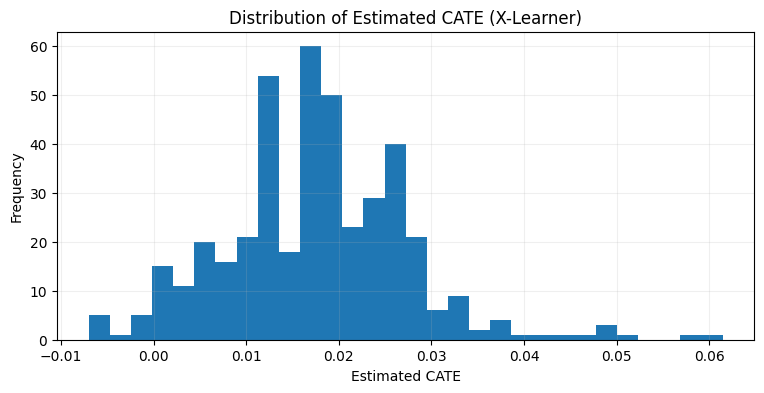

In [12]:
# ============================================================
# STEP 11. Plot CATE distribution
# ============================================================

plt.figure(figsize=(9, 4))

plt.hist(
    result["CATE_X"],
    bins=30
)

plt.title("Distribution of Estimated CATE (X-Learner)")
plt.xlabel("Estimated CATE")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)
plt.show()

## 13. CATE 상위/하위 사례 확인

어떤 시장 상태에서 효과가 크게 또는 작게 추정되는지 확인합니다.

In [13]:
# ============================================================
# STEP 12. Top and bottom CATE cases
# ============================================================

top_cases = (
    result
    .sort_values(
        "CATE_X",
        ascending=False
    )
    .head(10)
)

bottom_cases = (
    result
    .sort_values(
        "CATE_X",
        ascending=True
    )
    .head(10)
)

print("Top 10 X-Learner CATE cases")
display(top_cases)

print("Bottom 10 X-Learner CATE cases")
display(bottom_cases)

Top 10 X-Learner CATE cases


,mom_5d,vol_10d,log_volume,CATE_T,CATE_S,CATE_X
719,0.132959,0.032955,16.534962,0.109686,0.000000,0.061453
778,0.002464,0.090149,16.138976,0.087729,0.000000,0.058567
686,0.058756,0.042644,15.882626,0.062171,0.000000,0.051307
732,-0.027984,0.041775,15.927540,0.059019,0.000000,0.048124
1057,0.070745,0.022089,16.041193,0.063017,0.000027,0.047852
972,0.080949,0.022729,16.429331,0.075791,0.000148,0.047810
698,-0.045148,0.041014,15.714479,0.052406,0.000000,0.045880
742,0.103495,0.039410,16.550462,0.069652,0.000000,0.043544
762,0.106993,0.037890,16.540156,0.067360,0.000000,0.042861
970,0.108081,0.022193,16.899711,0.089007,0.000000,0.039157


Bottom 10 X-Learner CATE cases


,mom_5d,vol_10d,log_volume,CATE_T,CATE_S,CATE_X
2654,0.047307,0.015284,15.591107,-0.012102,-0.001960,-0.007014
2332,0.042264,0.014825,14.614143,-0.011973,-0.001443,-0.006976
2331,0.026161,0.014773,14.946074,-0.011320,-0.001266,-0.006298
1047,0.018576,0.013884,15.724549,-0.010227,-0.001127,-0.005474
1004,0.020443,0.016555,15.985832,-0.013527,-0.001597,-0.004993
2657,0.004178,0.014790,15.793072,-0.006793,-0.000025,-0.002856
2656,0.003019,0.014636,15.545501,-0.005604,-0.000031,-0.002311
1005,0.027257,0.017269,15.991738,-0.011016,-0.001515,-0.001842
1009,0.004952,0.014913,16.222465,-0.005947,0.000337,-0.001618
734,0.003431,0.037600,16.497217,-0.007711,-0.000191,-0.000444


## 14. learner별 평균 및 분산 비교

In [14]:
# ============================================================
# STEP 13. Compare learners
# ============================================================

learner_compare = pd.DataFrame({
    "Learner": [
        "T-Learner",
        "S-Learner",
        "X-Learner"
    ],
    "Mean CATE": [
        np.mean(cate_t),
        np.mean(cate_s),
        np.mean(cate_x)
    ],
    "Std. CATE": [
        np.std(cate_t),
        np.std(cate_s),
        np.std(cate_x)
    ],
    "Positive Share": [
        np.mean(cate_t > 0),
        np.mean(cate_s > 0),
        np.mean(cate_x > 0)
    ]
})

display(learner_compare)

,Learner,Mean CATE,Std. CATE,Positive Share
0,T-Learner,0.021450,0.018408,0.904762
1,S-Learner,0.001544,0.001897,0.747619
2,X-Learner,0.017574,0.009843,0.973810


## 15. 영어 + 한글 Meta-Learner 자동 추론 함수

In [15]:
# ============================================================
# STEP 14. Bilingual Meta-Learner inference
# ============================================================

def bilingual_meta_inference(
    cate_values,
    learner_name
):
    cate_values = np.asarray(cate_values)

    mean_cate = np.mean(cate_values)
    median_cate = np.median(cate_values)
    std_cate = np.std(cate_values)

    positive_share = np.mean(
        cate_values > 0
    )

    negative_share = np.mean(
        cate_values < 0
    )

    print("=" * 90)
    print(f"{learner_name} INFERENCE REPORT / {learner_name} 추론 결과")
    print("=" * 90)

    print(f"Mean CATE / 평균 CATE: {mean_cate:.6f}")
    print(f"Median CATE / 중앙값 CATE: {median_cate:.6f}")
    print(f"Std. CATE / CATE 표준편차: {std_cate:.6f}")
    print(f"Positive Share / 양(+) 효과 비율: {positive_share:.2%}")
    print(f"Negative Share / 음(-) 효과 비율: {negative_share:.2%}")

    if mean_cate > 0:
        en_mean = (
            f"On average, {learner_name} estimates a positive treatment effect "
            "for AI-related stocks in the post-event period."
        )
        ko_mean = (
            f"평균적으로 {learner_name}는 이벤트 이후 AI 관련 종목에 대해 "
            "양(+)의 처치효과를 추정합니다."
        )
    elif mean_cate < 0:
        en_mean = (
            f"On average, {learner_name} estimates a negative treatment effect "
            "for AI-related stocks in the post-event period."
        )
        ko_mean = (
            f"평균적으로 {learner_name}는 이벤트 이후 AI 관련 종목에 대해 "
            "음(-)의 처치효과를 추정합니다."
        )
    else:
        en_mean = (
            f"On average, {learner_name} estimates almost no treatment effect."
        )
        ko_mean = (
            f"평균적으로 {learner_name}가 추정한 처치효과는 거의 0에 가깝습니다."
        )

    if positive_share >= 0.60:
        en_hetero = (
            "A relatively large share of observations shows positive heterogeneous effects."
        )
        ko_hetero = (
            "상대적으로 많은 관측치에서 양(+)의 이질적 처치효과가 나타납니다."
        )
    elif positive_share >= 0.40:
        en_hetero = (
            "The heterogeneous effects are mixed across observations."
        )
        ko_hetero = (
            "관측치별 이질적 처치효과는 양(+)과 음(-)이 혼재되어 있습니다."
        )
    else:
        en_hetero = (
            "Positive heterogeneous effects are relatively limited."
        )
        ko_hetero = (
            "양(+)의 이질적 처치효과가 나타나는 관측치 비중은 상대적으로 제한적입니다."
        )

    print("\nEnglish interpretation:")
    print(en_mean)
    print(en_hetero)

    print("\n한글 해석:")
    print(ko_mean)
    print(ko_hetero)

    print("\nCausal Interpretation Note / 인과해석 주의")
    print(
        "EN: These estimates are educational CATE estimates. "
        "Treatment assignment is not randomized, so the estimates should not "
        "be interpreted as fully identified causal effects."
    )
    print(
        "KO: 본 결과는 교육용 CATE 추정치입니다. "
        "처치 배정이 무작위가 아니므로 완전히 식별된 인과효과로 해석해서는 안 됩니다."
    )

    print("=" * 90)


bilingual_meta_inference(
    cate_t,
    "T-Learner"
)

bilingual_meta_inference(
    cate_s,
    "S-Learner"
)

bilingual_meta_inference(
    cate_x,
    "X-Learner"
)

T-Learner INFERENCE REPORT / T-Learner 추론 결과
Mean CATE / 평균 CATE: 0.021450
Median CATE / 중앙값 CATE: 0.018012
Std. CATE / CATE 표준편차: 0.018408
Positive Share / 양(+) 효과 비율: 90.48%
Negative Share / 음(-) 효과 비율: 9.52%

English interpretation:
On average, T-Learner estimates a positive treatment effect for AI-related stocks in the post-event period.
A relatively large share of observations shows positive heterogeneous effects.

한글 해석:
평균적으로 T-Learner는 이벤트 이후 AI 관련 종목에 대해 양(+)의 처치효과를 추정합니다.
상대적으로 많은 관측치에서 양(+)의 이질적 처치효과가 나타납니다.

Causal Interpretation Note / 인과해석 주의
EN: These estimates are educational CATE estimates. Treatment assignment is not randomized, so the estimates should not be interpreted as fully identified causal effects.
KO: 본 결과는 교육용 CATE 추정치입니다. 처치 배정이 무작위가 아니므로 완전히 식별된 인과효과로 해석해서는 안 됩니다.
S-Learner INFERENCE REPORT / S-Learner 추론 결과
Mean CATE / 평균 CATE: 0.001544
Median CATE / 중앙값 CATE: 0.001328
Std. CATE / CATE 표준편차: 0.001897
Positive Share / 양(+) 효과 비율: 74.76%
Negative Share / 음(

## 16. 최종 Meta-Learner 비교 해석

In [16]:
# ============================================================
# STEP 15. Final bilingual learner comparison
# ============================================================

print("=" * 90)
print("FINAL META-LEARNER COMPARISON / 최종 META-LEARNER 비교")
print("=" * 90)

display(learner_compare)

best_mean_row = (
    learner_compare
    .sort_values(
        "Mean CATE",
        ascending=False
    )
    .iloc[0]
)

print(
    f"EN: The learner with the highest average estimated CATE is "
    f"{best_mean_row['Learner']} "
    f"({best_mean_row['Mean CATE']:.6f})."
)

print(
    f"KO: 평균 추정 CATE가 가장 큰 모형은 "
    f"{best_mean_row['Learner']}이며, "
    f"평균값은 {best_mean_row['Mean CATE']:.6f}입니다."
)

spread = learner_compare["Mean CATE"].max() - learner_compare["Mean CATE"].min()

if spread > 0.01:
    print(
        "EN: The estimated treatment effect is notably model-dependent."
    )
    print(
        "KO: 추정된 처치효과는 모형 선택에 따라 상당한 차이를 보입니다."
    )
else:
    print(
        "EN: The three learners produce relatively similar average treatment effects."
    )
    print(
        "KO: 세 learner의 평균 처치효과는 비교적 유사한 수준입니다."
    )

print("=" * 90)

FINAL META-LEARNER COMPARISON / 최종 META-LEARNER 비교


,Learner,Mean CATE,Std. CATE,Positive Share
0,T-Learner,0.021450,0.018408,0.904762
1,S-Learner,0.001544,0.001897,0.747619
2,X-Learner,0.017574,0.009843,0.973810


EN: The learner with the highest average estimated CATE is T-Learner (0.021450).
KO: 평균 추정 CATE가 가장 큰 모형은 T-Learner이며, 평균값은 0.021450입니다.
EN: The estimated treatment effect is notably model-dependent.
KO: 추정된 처치효과는 모형 선택에 따라 상당한 차이를 보입니다.


## 17. 최종 해석 포인트

1. 평균 CATE만 보지 말고 분포를 함께 봅니다.
2. 양(+) 효과 비율과 음(-) 효과 비율을 비교합니다.
3. 상위/하위 CATE 사례의 특성값을 확인합니다.
4. learner별 결과 차이를 통해 model dependence를 설명합니다.
5. 실제 연구에서는 time split, orthogonalization, DR/R-Learner 등을 추가합니다.